In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df=pd.read_csv("titanic_dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# we will remove useless columns and null columns
# we will drop PassengerId,Name,Ticket,Cabin
df.drop(columns=["Name","Ticket","Cabin","PassengerId"],inplace=True)

In [8]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

<Axes: >

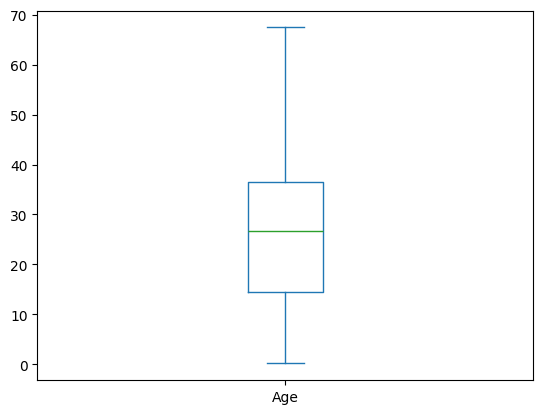

In [9]:
df["Age"].plot(kind="box")  # no outliers we can go with mean to fill null values

In [10]:
df["Age"]=df["Age"].fillna(df["Age"].mean())  # filled na values with mean

In [11]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64

In [12]:
# Fill Embarked column null values with mode of Embarked Column
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])  # zero in [] for accesing single value

<Axes: >

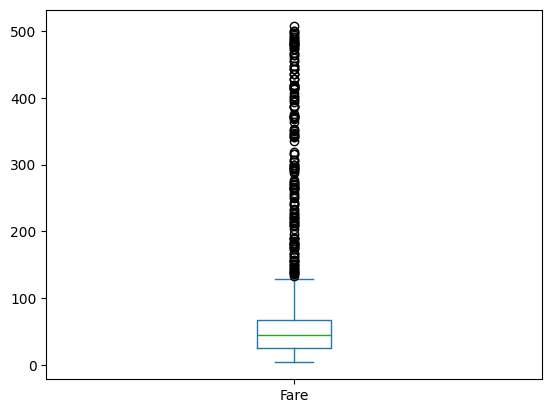

In [13]:
df["Fare"].plot(kind="box")

In [14]:
q1=df.describe()["Fare"]["25%"]

In [15]:
q3=df.describe()["Fare"]["75%"]

In [16]:
Iqr=q3-q1

In [17]:
# Lets use IQR technique to detect and cap the outlier values
upper_limit=q3+1.5*Iqr
lower_limit=q1-1.5*Iqr

In [18]:
df["Fare"]=df["Fare"].clip(lower_limit,upper_limit)

<Axes: >

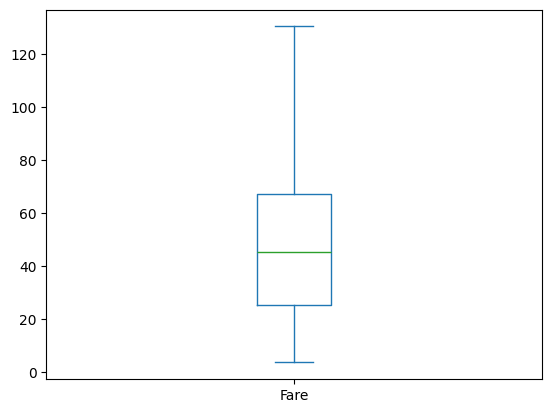

In [19]:
df["Fare"].plot(kind="box")

In [20]:
# Replacing Outliers with uPPER AND LOWER lIMIT Values
a1=df.describe()["Age"]["25%"]
a3=df.describe()["Age"]["75%"]
Iqr=a3-a1
upper_limit=a3+1.5*Iqr
lower_limit=a1-1.5*Iqr
df["Age"]=df["Age"].clip(lower_limit,upper_limit)

<Axes: >

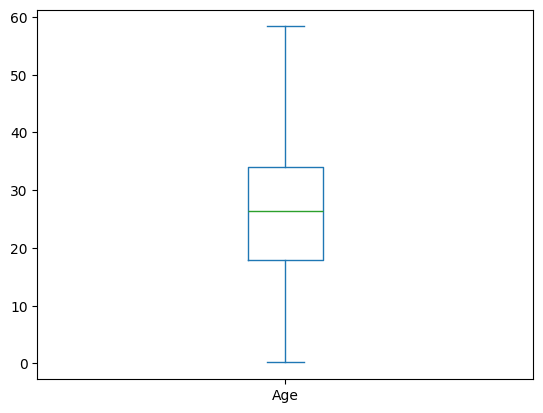

In [21]:
df["Age"].plot(kind="box")

In [22]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [23]:
# Nominal(sex,Embarked) or Ordinal 
df=pd.get_dummies(df,columns=["Sex","Embarked"],drop_first=True,dtype=np.int64)

In [24]:
X=df.drop(columns=["Survived"])   # Dependent Variable

In [25]:
y=df["Survived"]   # Independent Variable

In [26]:
# Split the dataset into 80 and 20 Percent
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [27]:
# for training X_test,y_test
# for Testing X_test will result in y_pred
# for Evaluation y_test,y_pred

from sklearn.linear_model import LogisticRegression
log=LogisticRegression()              # creating object or instance for class LogisticRegression
log.fit(X_train,y_train)

c:\Users\heman\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
# Testing
y_pred=log.predict(X_test)

In [41]:
y_test

495    0
648    1
278    1
31     0
255    1
      ..
167    0
306    1
379    0
742    1
10     0
Name: Survived, Length: 223, dtype: int64

In [30]:
# Evaluate the performance Confusion_matrix,Accuracy_score,precision,recall,f1_score
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

In [31]:
confusion_matrix(y_test,y_pred)

array([[134,   3],
       [ 80,   6]])

In [33]:
accuracy_score(y_test,y_pred)

0.6278026905829597

In [36]:
precision_score(y_test,y_pred)

0.6666666666666666

In [37]:
recall_score(y_test,y_pred)

0.06976744186046512

In [38]:
f1_score(y_test,y_pred)

0.12631578947368421